## 한국주택금융공사 주택금융관련 지수 머신러닝 분석

**목표**: 서울 소득대비 주택가격 비율(PIR)이 고부담 시기인지 저부담 시기인지 분류 (이진 분류)  
**모델**: 의사결정나무 (DecisionTreeClassifier)  
**데이터**: 2004년 ~ 2016년 초 (143개월, 17개 지역 PIR + 대출부담비율)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

# 한글 폰트 설정 (Windows)
import platform
from matplotlib import rc
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')

# 출력 형식 설정
np.set_printoptions(suppress=True, precision=4)
pd.options.display.float_format = '{:,.4f}'.format
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
plt.rcParams['font.size'] = 14

random_seed = 123

In [2]:
# 데이터 로드
df = pd.read_csv('input/한국주택금융공사_주택금융관련 지수_20160101.csv', encoding='euc-kr')

# 컬럼명 정리
df.columns = ['연도',
    'PIR_전국','PIR_서울','PIR_부산','PIR_대구','PIR_인천','PIR_광주','PIR_대전','PIR_울산','PIR_세종',
    'PIR_경기','PIR_강원','PIR_충북','PIR_충남','PIR_전북','PIR_전남','PIR_경북','PIR_경남','PIR_제주',
    'LTI_전국','LTI_서울','LTI_부산','LTI_대구','LTI_인천','LTI_광주','LTI_대전','LTI_울산','LTI_세종',
    'LTI_경기','LTI_강원','LTI_충북','LTI_충남','LTI_전북','LTI_전남','LTI_경북','LTI_경남','LTI_제주']

# 월 컬럼 복원 (연도 내 행 순서)
df['월'] = df.groupby('연도').cumcount() + 1

# 세종시 컬럼 제외 (2012년 이전 0값 다수 — 세종시 2012년 7월 출범)
df = df.drop(columns=['PIR_세종', 'LTI_세종'])

print(f'데이터 크기: {df.shape}')
print(f'기간: {df["연도"].iloc[0]}년 ~ {df["연도"].iloc[-1]}년')
print(f'결측치: {df.isnull().sum().sum()}')
print()
df[['연도', '월', 'PIR_전국', 'PIR_서울', 'LTI_전국', 'LTI_서울']].head()

데이터 크기: (143, 36)
기간: 2004년 ~ 2016년
결측치: 0



,연도,월,PIR_전국,PIR_서울,LTI_전국,LTI_서울
0,2004,1,4.2100,4.8900,2.3600,2.6100
1,2004,2,4.3900,5.5900,2.3900,2.8100
2,2004,3,4.1900,5.1400,2.2400,2.5200
3,2004,4,4.0900,4.3800,2.2400,2.2100
4,2004,5,4.2900,5.8800,2.3600,3.0000


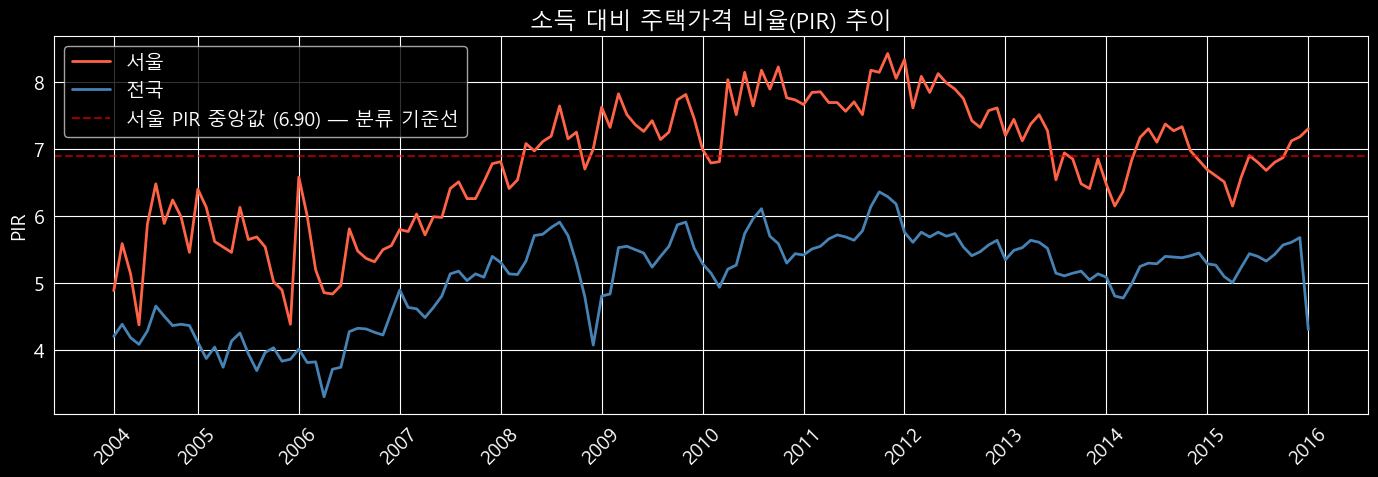

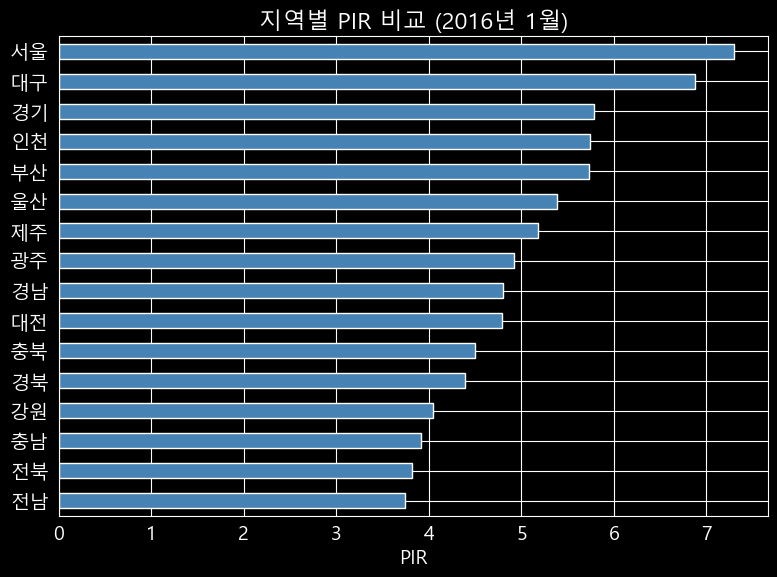

In [3]:
# 서울 vs 전국 PIR 추이
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['PIR_서울'], label='서울', color='tomato', linewidth=2)
plt.plot(df.index, df['PIR_전국'], label='전국', color='steelblue', linewidth=2)
median_pir = df['PIR_서울'].median()
plt.axhline(y=median_pir, color='red', linestyle='--', alpha=0.6,
            label=f'서울 PIR 중앙값 ({median_pir:.2f}) — 분류 기준선')
year_idx = df[df['월'] == 1].index
year_labels = df.loc[year_idx, '연도'].values
plt.xticks(year_idx, year_labels, rotation=45)
plt.title('소득 대비 주택가격 비율(PIR) 추이')
plt.ylabel('PIR')
plt.legend()
plt.tight_layout()
plt.show()

# 최근 시점 지역별 PIR 비교
pir_cols = [c for c in df.columns if c.startswith('PIR_') and c != 'PIR_전국']
last = df.iloc[-1]
pd.Series(last[pir_cols].values, index=[c.replace('PIR_', '') for c in pir_cols]) \
    .sort_values().plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title(f'지역별 PIR 비교 ({int(last["연도"])}년 {int(last["월"])}월)')
plt.xlabel('PIR')
plt.tight_layout()
plt.show()

In [4]:
# adult.csv의 income 처리와 동일한 패턴
# 서울 PIR 중앙값 기준으로 고부담/저부담 이진화
median_pir = df['PIR_서울'].median()
print(f'서울 PIR 중앙값: {median_pir}')
print(f'서울 PIR 범위: {df["PIR_서울"].min()} ~ {df["PIR_서울"].max()}')
print()

df['서울_부담수준'] = np.where(df['PIR_서울'] >= median_pir, 'high', 'low')

print('서울 부담수준 분포:')
print(df['서울_부담수준'].value_counts(normalize=True))

서울 PIR 중앙값: 6.9
서울 PIR 범위: 4.38 ~ 8.42

서울 부담수준 분포:
서울_부담수준
high   0.5035
low    0.4965
Name: proportion, dtype: float64


In [5]:
# 피처(X): 서울 PIR 제외, 전국·주요 지역 PIR + 대출부담비율 + 연도/월
feature_cols = ['연도', '월',
                'PIR_전국', 'PIR_부산', 'PIR_대구', 'PIR_인천', 'PIR_경기',
                'LTI_전국', 'LTI_서울']

X = df[feature_cols]
y = df['서울_부담수준']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_seed)

print(f'학습 데이터: {len(X_train)}행')
print(f'테스트 데이터: {len(X_test)}행')
print()
print('타겟 분포 (전체):')
print(y.value_counts(normalize=True))

학습 데이터: 114행
테스트 데이터: 29행

타겟 분포 (전체):
서울_부담수준
high   0.5035
low    0.4965
Name: proportion, dtype: float64


In [6]:
from sklearn import tree as sktree

clf = sktree.DecisionTreeClassifier(random_state=random_seed, max_depth=3)
model = clf.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('=== 의사결정나무 분류 결과 ===')
print(f'정확도(Accuracy): {accuracy_score(y_test, y_pred):.4f}')
print()
print('혼동행렬:')
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

=== 의사결정나무 분류 결과 ===
정확도(Accuracy): 0.8276

혼동행렬:
[[ 6  2]
 [ 3 18]]

              precision    recall  f1-score   support

        high       0.67      0.75      0.71         8
         low       0.90      0.86      0.88        21

    accuracy                           0.83        29
   macro avg       0.78      0.80      0.79        29
weighted avg       0.84      0.83      0.83        29



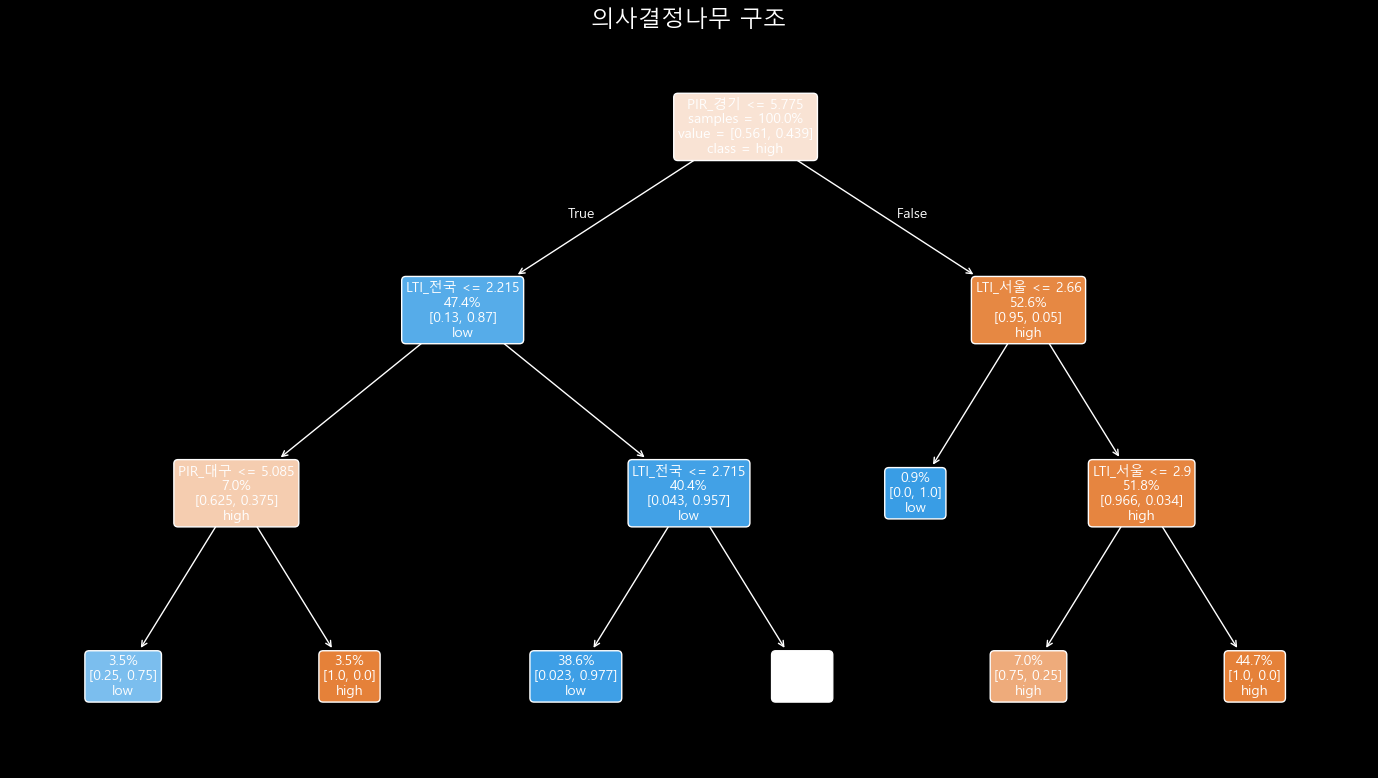

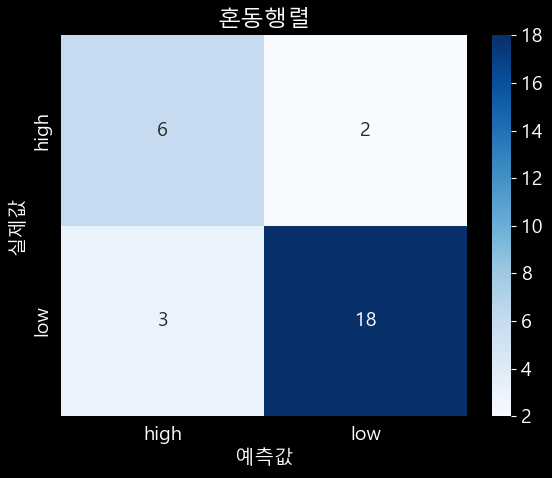

In [7]:
from sklearn import tree

# 의사결정나무 시각화
plt.rcParams.update({'figure.figsize': [14, 8], 'figure.dpi': 100})
tree.plot_tree(model,
               feature_names=feature_cols,
               class_names=['high', 'low'],
               proportion=True,
               filled=True,
               rounded=True,
               impurity=False,
               label='root',
               fontsize=10)
plt.title('의사결정나무 구조')
plt.tight_layout()
plt.show()

# 혼동행렬 시각화
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['high', 'low'],
            yticklabels=['high', 'low'])
plt.title('혼동행렬')
plt.xlabel('예측값')
plt.ylabel('실제값')
plt.tight_layout()
plt.show()